# Real-Strategy Cross-Framework Audit

This notebook reports the current framework comparison on three production-selected case-study
strategies: ETF allocation, CME futures, and crypto perpetual futures with funding. Every engine
in a required pair receives the same content-addressed market data and frozen model-derived
targets. Unsupported pairs are disclosed instead of being approximated with a different asset or
accounting model.

The result is narrower than universal framework equivalence. Six of eight supported pairs pass.
The two CME comparisons reproduce every fill but fail the equity and terminal-value checks at the
audit's `1e-8` canonical quantum.

**Learning objectives**

- Read a parity result across fills, valuation timestamps, equity, and terminal value
- Separate supported comparisons from asset models a framework does not provide
- Interpret engine-only timings without generalizing beyond the measured workload and machine
- Distinguish real-strategy evidence from synthetic convention and stress tests

**Book reference**: Chapter 16, Section 16.3

## Setup

In [1]:
"""Current real-strategy cross-framework audit."""

import json

import matplotlib.pyplot as plt
import polars as pl
from IPython.display import Markdown, display

from utils.paths import get_chapter_dir

In [2]:
# Production defaults - Papermill injects overrides after this cell
ROUND_SECONDS = 3

In [3]:
AUDIT_PATH = get_chapter_dir(16) / "resources" / "framework_parity_audit.json"
audit = json.loads(AUDIT_PATH.read_text(encoding="utf-8"))

assert audit["schema_version"] == 1
assert audit["scope"]["required_pairs"] == 8
assert audit["scope"]["unsupported_pairs"] == 7

FRAMEWORK_NAMES = {
    key: f"{value['display_name']} {value['version']}" for key, value in audit["frameworks"].items()
}
CASE_NAMES = {
    "etfs": "ETF allocation",
    "cme_futures": "CME futures",
    "crypto_perps_funding": "Crypto perpetual funding",
}

display(
    Markdown(
        f"**Evidence date:** {audit['audit_generated_at'][:10]}  \n"
        f"**Library evidence commit:** `{audit['library_commit'][:12]}`"
    )
)

**Evidence date:** 2026-08-20  
**Library evidence commit:** `3e2c88fda6df`

## 1. What is compared

Model fitting and target construction happen before either engine runs. The same frozen target
table is identified by its input-bundle hash on both sides of a comparison. This audit therefore
tests backtest execution, not whether two modeling pipelines happen to produce similar signals.

A pass requires all of the following:

- the complete sorted fill stream matches on timestamp, asset, side, quantity, price, and commission;
- the engines expose the same valuation timestamp set;
- every valuation and the terminal value have zero gap after `1e-8` quantization; and
- a negative control that changes the first fill price by exactly `1e-8` is detected.

"Exact" does not mean bit-identical floating-point state.

In [4]:
bundle_table = (
    pl.DataFrame(audit["real_strategy_records"])
    .select("case_study", "input_bundle_sha256")
    .unique()
    .with_columns(
        pl.col("case_study").replace_strict(CASE_NAMES).alias("strategy"),
        pl.col("input_bundle_sha256").str.slice(0, 12).alias("bundle_sha256_prefix"),
    )
    .select("strategy", "bundle_sha256_prefix")
    .sort("strategy")
)
display(bundle_table)

strategy,bundle_sha256_prefix
str,str
"""CME futures""","""c7191027f550"""
"""Crypto perpetual funding""","""2acee3c85420"""
"""ETF allocation""","""01f38079ce47"""


The bundle hash covers the prepared market data, frozen targets, strategy specification, and any
contract or funding inputs required by the case study.

## 2. Current correctness result

In [5]:
results = (
    pl.DataFrame(audit["real_strategy_records"])
    .with_columns(
        pl.col("case_study").replace_strict(CASE_NAMES).alias("strategy"),
        pl.col("framework").replace_strict(FRAMEWORK_NAMES).alias("engine"),
    )
    .select(
        "strategy",
        "engine",
        "status",
        "fills",
        "valuations",
        "valuation_timestamps_match",
        "equity_gap",
        "terminal_gap",
        "negative_control_detected",
    )
    .sort("strategy", "engine")
)

passing = results.filter(pl.col("status") == "pass").height
assert passing == audit["scope"]["passing_pairs"] == 6
assert results["valuation_timestamps_match"].all()
assert results["negative_control_detected"].all()

display(results)

strategy,engine,status,fills,valuations,valuation_timestamps_match,equity_gap,terminal_gap,negative_control_detected
str,str,str,i64,i64,bool,str,str,bool
"""CME futures""","""Backtrader 1.9.78.123""","""fail""",3376,1595,true,"""0.00000015""","""0.00000015""",true
"""CME futures""","""VectorBT Pro 2026.6.27""","""fail""",3545,1595,true,"""0.00000010""","""0.00000007""",true
"""Crypto perpetual funding""","""LEAN 18001""","""pass""",8408,2426,true,"""0.00000000""","""0.00000000""",true
"""ETF allocation""","""Backtrader 1.9.78.123""","""pass""",2433,1995,true,"""0.00000000""","""0.00000000""",true
"""ETF allocation""","""LEAN 18001""","""pass""",2457,1995,true,"""0.00000000""","""0.00000000""",true
"""ETF allocation""","""VectorBT OSS 1.1.0""","""pass""",2466,1995,true,"""0.00000000""","""0.00000000""",true
"""ETF allocation""","""VectorBT Pro 2026.6.27""","""pass""",2466,1995,true,"""0.00000000""","""0.00000000""",true
"""ETF allocation""","""Zipline Reloaded 3.1.1""","""pass""",2458,1995,true,"""0.00000000""","""0.00000000""",true


In [6]:
display(
    Markdown(
        f"**Result:** {passing}/{results.height} supported pairs pass. The broad real-strategy "
        "equivalence gate remains **failed** because both CME rows exceed the exact comparison "
        "quantum on equity and terminal value."
    )
)

**Result:** 6/8 supported pairs pass. The broad real-strategy equivalence gate remains **failed** because both CME rows exceed the exact comparison quantum on equity and terminal value.

All five ETF engines match ML4T Backtest across thousands of fills and 1,995 valuations. LEAN also
matches the crypto-perpetual strategy across 8,408 fills and 2,426 hourly valuations, including
native funding settlements. The CME comparisons have identical fill streams and timestamp
coverage, but their maximum equity gaps are `0.00000010` for VectorBT Pro and `0.00000015` for
Backtrader. Those rows fail because the audit does not replace an exact gate with an economic
tolerance.

## 3. Unsupported pairs

A comparison is required only when the external engine and the frozen input can express the asset
contract without substituting different semantics. For example, the current CME bundle contains
continuous root series but no dated contract chain or roll map, so it is not a valid LEAN or
Zipline futures input.

In [7]:
unsupported = (
    pl.DataFrame(audit["unsupported_records"])
    .with_columns(
        pl.col("case_study").replace_strict(CASE_NAMES).alias("strategy"),
        pl.col("framework").replace_strict(FRAMEWORK_NAMES).alias("engine"),
    )
    .select("strategy", "engine", "reason")
    .sort("strategy", "engine")
)
display(unsupported)

strategy,engine,reason
str,str,str
"""CME futures""","""LEAN 18001""","""the frozen workload has contin…"
"""CME futures""","""VectorBT OSS 1.1.0""","""no native futures contract mul…"
"""CME futures""","""Zipline Reloaded 3.1.1""","""the frozen workload has contin…"
"""Crypto perpetual funding""","""Backtrader 1.9.78.123""","""no native perpetual-futures fu…"
"""Crypto perpetual funding""","""VectorBT OSS 1.1.0""","""no native perpetual-futures fu…"
"""Crypto perpetual funding""","""VectorBT Pro 2026.6.27""","""no native perpetual-futures fu…"
"""Crypto perpetual funding""","""Zipline Reloaded 3.1.1""","""no crypto perpetual-futures as…"


These rows are not failures and do not count as passes. They define where this audit has no valid
comparison.

## 4. Engine-only runtime

Timing is reported only for correctness-passing pairs. Each row uses one warmup and ten measured,
process-isolated runs. The timed region is the engine call. It excludes data loading, model
inference, target construction, adapter preparation, output extraction, serialization, and
reporting.

In [8]:
performance = (
    pl.DataFrame(audit["performance_records"])
    .with_columns(
        pl.col("case_study").replace_strict(CASE_NAMES).alias("strategy"),
        pl.col("framework").replace_strict(FRAMEWORK_NAMES).alias("engine"),
    )
    .with_columns(
        pl.col("framework_median_seconds").round(ROUND_SECONDS).alias("external_seconds"),
        pl.col("ml4t_median_seconds").round(ROUND_SECONDS).alias("ml4t_seconds"),
        pl.col("framework_to_ml4t_ratio").round(2).alias("external_div_ml4t"),
    )
    .select(
        "strategy",
        "engine",
        "external_seconds",
        "ml4t_seconds",
        "external_div_ml4t",
    )
)
display(performance)

strategy,engine,external_seconds,ml4t_seconds,external_div_ml4t
str,str,f64,f64,f64
"""ETF allocation""","""VectorBT Pro 2026.6.27""",0.28,0.454,0.62
"""ETF allocation""","""VectorBT OSS 1.1.0""",0.167,0.453,0.37
"""ETF allocation""","""Backtrader 1.9.78.123""",9.077,0.408,22.26
"""ETF allocation""","""Zipline Reloaded 3.1.1""",3.689,0.396,9.32
"""ETF allocation""","""LEAN 18001""",2.744,0.512,5.36
"""Crypto perpetual funding""","""LEAN 18001""",2.698,0.622,4.34


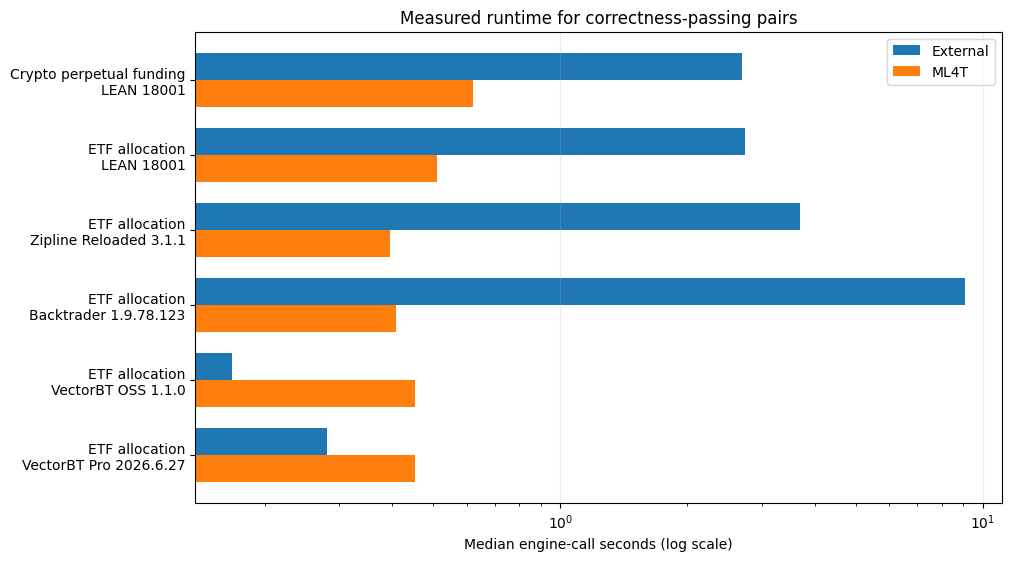

In [9]:
plot_data = performance.to_pandas()
labels = [f"{row.strategy}\n{row.engine}" for row in plot_data.itertuples()]
y = list(range(len(plot_data)))
height = 0.36

fig, ax = plt.subplots(figsize=(10, 5.5), layout="constrained")
ax.barh(
    [value + height / 2 for value in y], plot_data["external_seconds"], height, label="External"
)
ax.barh([value - height / 2 for value in y], plot_data["ml4t_seconds"], height, label="ML4T")
ax.set_yticks(y, labels)
ax.set_xscale("log")
ax.set_xlabel("Median engine-call seconds (log scale)")
ax.set_title("Measured runtime for correctness-passing pairs")
ax.legend()
ax.grid(axis="x", alpha=0.25)
plt.show()

VectorBT is faster on the ETF workload. ML4T is faster than Backtrader, Zipline, and LEAN on the
measured rows. These are dated case-and-machine measurements, not stable framework-wide speed
rankings.

## 5. What the evidence supports

The current evidence supports exact ETF equivalence for all five engines and exact
crypto-perpetual equivalence for LEAN under the named profiles and frozen inputs. It does not
support a universal equivalence claim because the CME equity paths still fail, and it says nothing
about unsupported asset-framework combinations. The separate synthetic scenario and 250-asset
stress suites test convention coverage and scale after this real-strategy result; they do not
replace it.